# Griffiths Problem 1.16 -- fully worked, every step
**Problem.** Sketch `v = r-hat / r^2` and compute its divergence. The answer may
surprise you -- explain it.

This notebook shows every algebraic step *and* verifies each one (SymPy for the
divergence, NumPy for the flux), so nothing is taken on faith.

## Step 0 -- what the field looks like
`r-hat` points radially outward; `1/r^2` is its length. So `v` points away from the
origin everywhere, getting weaker with distance. It *looks* like it spreads out
everywhere -- hold that thought.

radial field, length 1/r^2 -- looks like it diverges everywhere


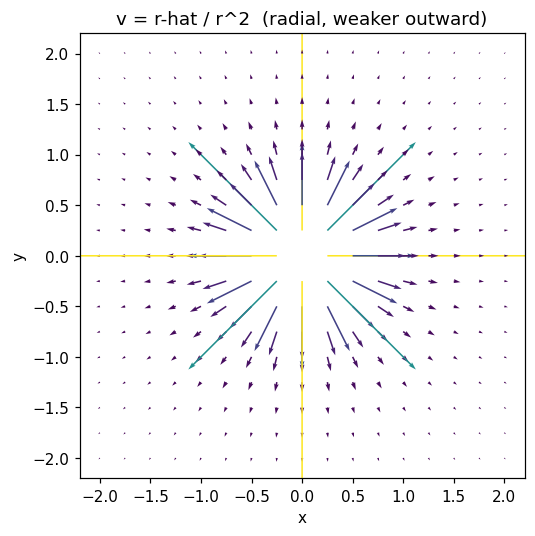

In [ ]:
import numpy as np, matplotlib.pyplot as plt
# 2-D slice of v = r-hat/r^2: arrows radiating out, shrinking with r
g = np.linspace(-2, 2, 17); X, Y = np.meshgrid(g, g)
R = np.sqrt(X**2 + Y**2); R[R == 0] = np.nan
U, V = X / R**3, Y / R**3                      # direction r-hat, magnitude ~1/r^2
plt.figure(figsize=(5, 5))
plt.quiver(X, Y, U, V, 1/R**2, cmap="viridis")
plt.title("v = r-hat / r^2  (radial, weaker outward)"); plt.gca().set_aspect("equal")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()
print("radial field, length 1/r^2 -- looks like it diverges everywhere")

## Step 1 -- write v in Cartesian
`r-hat = (x x-hat + y y-hat + z z-hat)/r` and `r = (x^2+y^2+z^2)^(1/2)`, so
```
v = r-hat/r^2 = r_vec/r^3 = (x/r^3, y/r^3, z/r^3),   r^3 = (x^2+y^2+z^2)^(3/2).
```

In [ ]:
import sympy as sp
x, y, z = sp.symbols("x y z", real=True)
r = sp.sqrt(x**2 + y**2 + z**2)
vx, vy, vz = x/r**3, y/r**3, z/r**3
print("v_x =", vx)
print("v_y =", vy)
print("v_z =", vz)

v_x = x/(x**2 + y**2 + z**2)**(3/2)
v_y = y/(x**2 + y**2 + z**2)**(3/2)
v_z = z/(x**2 + y**2 + z**2)**(3/2)


## Steps 2-3 -- differentiate each component (full product + chain rule)
For the x-component, `d/dx[x*(x^2+y^2+z^2)^(-3/2)]` is a product `x * f`:
- `u' f` term: `1 * (..)^(-3/2) = 1/r^3`
- `u f'` term: `x * (-3/2)(..)^(-5/2)*(2x) = -3x^2/r^5`

so `d v_x/dx = 1/r^3 - 3x^2/r^5`, and by symmetry the same with `y^2`, `z^2`.

In [ ]:
dvx = sp.simplify(sp.diff(vx, x))
print("d v_x / d x =", dvx, "   (= 1/r^3 - 3x^2/r^5)")
print("d v_y / d y =", sp.simplify(sp.diff(vy, y)))
print("d v_z / d z =", sp.simplify(sp.diff(vz, z)))

d v_x / d x = (-2*x**2 + y**2 + z**2)/(x**2 + y**2 + z**2)**(5/2)    (= 1/r^3 - 3x^2/r^5)
d v_y / d y = (x**2 - 2*y**2 + z**2)/(x**2 + y**2 + z**2)**(5/2)
d v_z / d z = (x**2 + y**2 - 2*z**2)/(x**2 + y**2 + z**2)**(5/2)


## Step 4 -- add them and simplify
```
div v = (1/r^3 - 3x^2/r^5) + (1/r^3 - 3y^2/r^5) + (1/r^3 - 3z^2/r^5)
      = 3/r^3 - 3(x^2+y^2+z^2)/r^5 = 3/r^3 - 3r^2/r^5 = 3/r^3 - 3/r^3 = 0.
```
**Valid only for r != 0** -- every term has r in a denominator; at r=0 it is undefined.

In [ ]:
div = sp.simplify(sp.diff(vx, x) + sp.diff(vy, y) + sp.diff(vz, z))
print("div v =", div, "   (zero everywhere EXCEPT the origin, where the formula blows up)")

div v = 0    (zero everywhere EXCEPT the origin, where the formula blows up)


## Steps 5-6 -- the paradox, and the divergence-theorem test
The picture says "diverges everywhere"; the algebra says 0. Resolve it with the
integral form. The divergence theorem: `integral_V (div v) dtau = surface_integral_S v.da`.
Take S = a sphere of radius R about the origin. There `v = r-hat/R^2` and
`da = R^2 sin(theta) dtheta dphi r-hat`, so
```
v . da = (1/R^2)(R^2) sin(theta) dtheta dphi = sin(theta) dtheta dphi,
flux = integral_0^2pi integral_0^pi sin(theta) dtheta dphi = (2pi)(2) = 4 pi,
```
**independent of R.**

In [ ]:
# numerical surface integral of v.da = sin(theta) dtheta dphi over the sphere
th = np.linspace(0, np.pi, 400); ph = np.linspace(0, 2*np.pi, 800)
integrand = np.outer(np.ones_like(ph), np.sin(th))
for Rv in (0.5, 1.0, 5.0):
    flux = np.trapezoid(np.trapezoid(integrand, th, axis=1), ph)   # R cancels in v.da
    print(f"flux through sphere R={Rv}: {flux:.5f}   (4 pi = {4*np.pi:.5f})")

flux through sphere R=0.5: 12.56631   (4 pi = 12.56637)
flux through sphere R=1.0: 12.56631   (4 pi = 12.56637)
flux through sphere R=5.0: 12.56631   (4 pi = 12.56637)


## Steps 7-8 -- the contradiction and its resolution (the Dirac delta)
If `div v = 0` everywhere, the volume integral would be 0 -- but the flux is `4 pi`.
So `div v` is **not** zero everywhere; it carries a spike at `r = 0` (the point we
skipped) whose integral is `4 pi`. The object that is zero everywhere except one point
yet integrates to a finite value is the **3-D Dirac delta**:
```
+-------------------------------------+
|   div( r-hat / r^2 ) = 4 pi delta^3(r)   |
+-------------------------------------+
```
Check: `integral 4 pi delta^3(r) dtau = 4 pi` (matches the flux), and `= 0` for r != 0
(matches Step 4). Both halves are now consistent.

In [ ]:
# the delta strength = the flux (divergence theorem), independent of the volume
print("integral of div v over any volume containing 0  =  flux  =  4 pi  =", round(4*np.pi, 5))
print("=> div(r-hat/r^2) = 4 pi * delta^3(r): zero off-origin, a 4-pi spike at r=0")

integral of div v over any volume containing 0  =  flux  =  4 pi  = 12.56637
=> div(r-hat/r^2) = 4 pi * delta^3(r): zero off-origin, a 4-pi spike at r=0


## Step 9 -- why it matters (the physics)
This is **Gauss's law**. A point charge has `E = (q/4 pi eps0)(r-hat/r^2)`, so
```
div E = (q/4 pi eps0) * 4 pi delta^3(r) = (q/eps0) delta^3(r) = rho/eps0,
```
because the charge density of a point charge is `rho = q delta^3(r)` -- all the charge
at one point, and the divergence of E sits exactly there.

**Bonus:** since `grad(1/r) = -r-hat/r^2`, we have `v = -grad(1/r)`, hence
`div v = -laplacian(1/r)`, giving `laplacian(1/r) = -4 pi delta^3(r)` -- the Green's
function of the Laplacian, used all through Chapters 2-3.

### One line for the board
`div(r-hat/r^2) = 0` in empty space, but the flux through *every* sphere is `4 pi`, so
all the divergence is a `4 pi` delta spike at the origin: **`div(r-hat/r^2) = 4 pi delta^3(r)`** -- Gauss's law for a point charge.